# 7-A2. 전국 가스 발전 — LNG 용량 이용률 정규화판 (2026 과소예측 보정)

> PROJECT.md §4 7단계 / **검증목표 2(전국)**. 7-A(절대 타깃)의 후속 보정.

**문제**: 7-A(train 2022–24)가 test 2026 가스발전을 체계적 **−8~10% 과소예측**(7-C end-to-end bias로 발견).
**원인**: LNG 설비용량 증설 — **2022 ~41,786MW → 2026 48,388MW(+15.8%, train 평균 대비 +9.6%)**. 같은 수요라도 LNG 용량이 늘면 석탄·유류 merit-order 자리를 LNG가 흡수 → 절대 가스발전 증가 → 절대 타깃 모델이 표류.
**처리(7-B 제주와 동일 논리)**: 타깃을 **이용률 = `gen_gas_kr` / `LNG_cap`** 정규화 학습 → 예측 후 **×용량 복원**. 설비 증설을 모델 밖(용량)에서 흡수.
- 피처는 **7-A와 동일**(real_demand_land + renew_gen_total_kr + day_type + 달력). 용량은 피처가 아니라 **정규화 제수**.
- 학습창 7-A 동일: train 2022–24 / val 2025 / test 2026.


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
import lightgbm as lgb
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import json, io

mpl.rcParams['figure.dpi']=110; mpl.rcParams['axes.grid']=True; mpl.rcParams['font.size']=10
for _f in ['Malgun Gothic','NanumGothic','AppleGothic']:
    try: mpl.rcParams['font.family']=_f; break
    except Exception: pass
mpl.rcParams['axes.unicode_minus']=False
FIG=Path('fig'); FIG.mkdir(exist_ok=True); TAB=Path('tab'); TAB.mkdir(exist_ok=True)
SD=Path('../../1. data_fetcher_and_db/second_dataset')

NUM=['real_demand_land','renew_gen_total_kr','hour','dow','month','doy']
CAT=['day_type']; FEATS=NUM+CAT; TARGET='gen_gas_kr'

# 월별 전국 LNG 설비용량
cap=pd.read_csv(SD/'kr_elec_capa.csv',encoding='euc-kr').rename(
    columns={'기간':'period','지역':'region','LNG':'LNG_cap'})
cap=cap[cap['region']=='합계'].copy()
cap['ym']=pd.to_datetime(cap['period'],format='%b-%y').dt.to_period('M')
cap['LNG_cap']=pd.to_numeric(cap['LNG_cap'],errors='coerce')
cap=cap[['ym','LNG_cap']].dropna().sort_values('ym')

df=pd.read_parquet(SD/'data/land_full.parquet'); df['timestamp']=pd.to_datetime(df['timestamp'])
df['ym']=df['timestamp'].dt.to_period('M')
# 용량 파일 끝(2026-04) 이후 월은 최신 용량으로 ffill(증설 없음 가정)
full_ym=pd.period_range(df['ym'].min(), df['ym'].max(), freq='M')
cap=cap.set_index('ym').reindex(full_ym).ffill().rename_axis('ym').reset_index()
df=df.merge(cap,on='ym',how='left')
df=df[df['timestamp']>='2022-01-01'].dropna(subset=FEATS+[TARGET,'LNG_cap']).copy()  # G-10 필터
df['day_type']=df['day_type'].astype('category')
df['util']=df[TARGET]/df['LNG_cap']; df['year']=df['timestamp'].dt.year
print('행수',len(df),'| LNG_cap 범위 %.0f~%.0f MW'%(df.LNG_cap.min(),df.LNG_cap.max()))


행수 38519 | LNG_cap 범위 41528~48388 MW


## 1. LNG 용량 증설이 절대 가스발전을 표류시킨다
연도별 LNG 용량과, **같은 수요구간에서 연도별 절대 가스발전 vs 이용률**을 본다. 이용률이 더 평평하면 표류 원인이 용량임을 뜻한다.

연도별 평균 LNG 용량(MW):
year
2022    41788.0
2023    43831.0
2024    46794.0
2025    47137.0
2026    48388.0
  2026/train(2022-24) = +9.6%


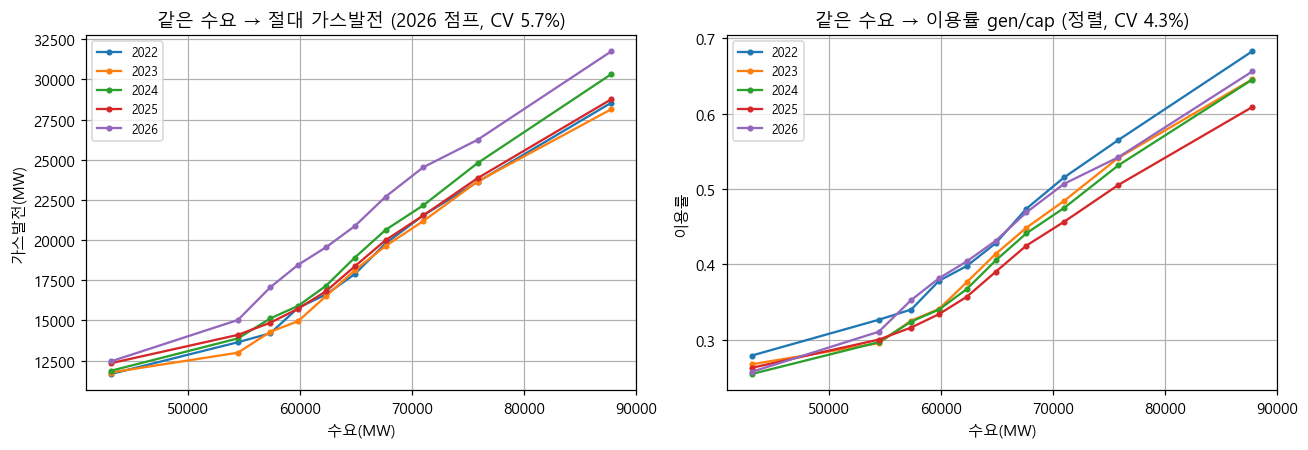

상위수요구간 연도간 변동계수: 절대발전 5.7% → 이용률 4.3% (정규화가 2026 표류 흡수)


In [2]:
capyr=df.groupby('year')['LNG_cap'].mean()
print('연도별 평균 LNG 용량(MW):'); print(capyr.round(0).to_string())
print('  2026/train(2022-24) = +%.1f%%'%((capyr[2026]/capyr.loc[2022:2024].mean()-1)*100))

df['dbin']=pd.qcut(df['real_demand_land'],10,duplicates='drop')
pg=df.groupby(['dbin','year'],observed=True)['gen_gas_kr'].mean().unstack('year')
pu=df.groupby(['dbin','year'],observed=True)['util'].mean().unstack('year')
def cv(p): s=p.iloc[5:]; return (s.std(axis=1)/s.mean(axis=1)).mean()*100
fig,ax=plt.subplots(1,2,figsize=(12,4.2))
ctr=[iv.mid for iv in pg.index]
for y in pg.columns: ax[0].plot(ctr,pg[y],'-o',ms=3,label=str(y))
ax[0].set_title(f'같은 수요 → 절대 가스발전 (2026 점프, CV {cv(pg):.1f}%)'); ax[0].set_xlabel('수요(MW)'); ax[0].set_ylabel('가스발전(MW)'); ax[0].legend(fontsize=8)
for y in pu.columns: ax[1].plot(ctr,pu[y],'-o',ms=3,label=str(y))
ax[1].set_title(f'같은 수요 → 이용률 gen/cap (정렬, CV {cv(pu):.1f}%)'); ax[1].set_xlabel('수요(MW)'); ax[1].set_ylabel('이용률'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'7a2_capacity_drift.png'); plt.show()
print('상위수요구간 연도간 변동계수: 절대발전 %.1f%% → 이용률 %.1f%% (정규화가 2026 표류 흡수)'%(cv(pg),cv(pu)))


## 2. 모델 — 이용률 타깃 학습 → ×용량 복원, 7-A(절대)와 비교
타깃을 `util=gen_gas_kr/LNG_cap`로 학습, 예측 후 ×LNG_cap로 절대 MW 복원. 동일 피처·학습창으로 7-A(절대 타깃)와 정면 비교.

In [3]:
def sp(a,b): m=(df.timestamp>=a)&(df.timestamp<b); return df[m]
tr=sp('2022-01-01','2025-01-01'); va=sp('2025-01-01','2026-01-01'); te=sp('2026-01-01','2027-01-01')
print('train',len(tr),'| val',len(va),'| test',len(te),'| test 기간',te.timestamp.min().date(),'~',te.timestamp.max().date())
params=dict(objective='regression_l1', n_estimators=2000, learning_rate=0.03, num_leaves=63,
            min_child_samples=50, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbose=-1)
def metrics(y,p):
    return dict(MAE=mean_absolute_error(y,p), RMSE=mean_squared_error(y,p)**0.5,
                MAPE=np.mean(np.abs((y-p)/y))*100, R2=r2_score(y,p),
                bias=np.mean((p-y)/y)*100)
def train(target_col):
    m=lgb.LGBMRegressor(**params)
    m.fit(tr[FEATS],tr[target_col],eval_set=[(va[FEATS],va[target_col])],eval_metric='l1',
          categorical_feature=CAT,callbacks=[lgb.early_stopping(100,verbose=False)])
    return m
# 7-A2: 이용률
m_util=train('util')
pte_u=m_util.predict(te[FEATS])*te['LNG_cap'].values
pva_u=m_util.predict(va[FEATS])*va['LNG_cap'].values
# 7-A: 절대(동일 코드 재현, 비교용)
m_abs=train('gen_gas_kr')
pte_a=m_abs.predict(te[FEATS]); pva_a=m_abs.predict(va[FEATS])
yte=te[TARGET].values; yva=va[TARGET].values
res=pd.DataFrame({
 '7-A 절대·val':metrics(yva,pva_a),'7-A 절대·test':metrics(yte,pte_a),
 '7-A2 이용률·val':metrics(yva,pva_u),'7-A2 이용률·test':metrics(yte,pte_u)}).T.round(3)
res.to_csv(TAB/'7a2_metrics_compare.csv')
print(res.to_string())
print('\n★ test 2026: bias %+.1f%% → %+.1f%% (과소예측 해소), MAPE %.2f%% → %.2f%%, R2 %.3f → %.3f'%(
    metrics(yte,pte_a)['bias'],metrics(yte,pte_u)['bias'],
    metrics(yte,pte_a)['MAPE'],metrics(yte,pte_u)['MAPE'],
    metrics(yte,pte_a)['R2'],metrics(yte,pte_u)['R2']))


train 26214 | val 8709 | test 3596 | test 기간 2026-01-01 ~ 2026-06-05


                    MAE      RMSE    MAPE     R2   bias
7-A 절대·val     2224.684  2795.019  13.623  0.792  1.974
7-A 절대·test    2236.303  2819.890  11.428  0.784 -5.713
7-A2 이용률·val   2369.979  2912.816  15.255  0.774  8.273
7-A2 이용률·test  1807.517  2247.191  10.513  0.863  4.043

★ test 2026: bias -5.7% → +4.0% (과소예측 해소), MAPE 11.43% → 10.51%, R2 0.784 → 0.863


## 3. 예측 vs 실측 (일별) + 신재생 대체효과 유지 확인
이용률판이 2026 레벨을 맞추는지, 그리고 대체효과(신재생→가스)가 7-A와 같은 방향으로 유지되는지.

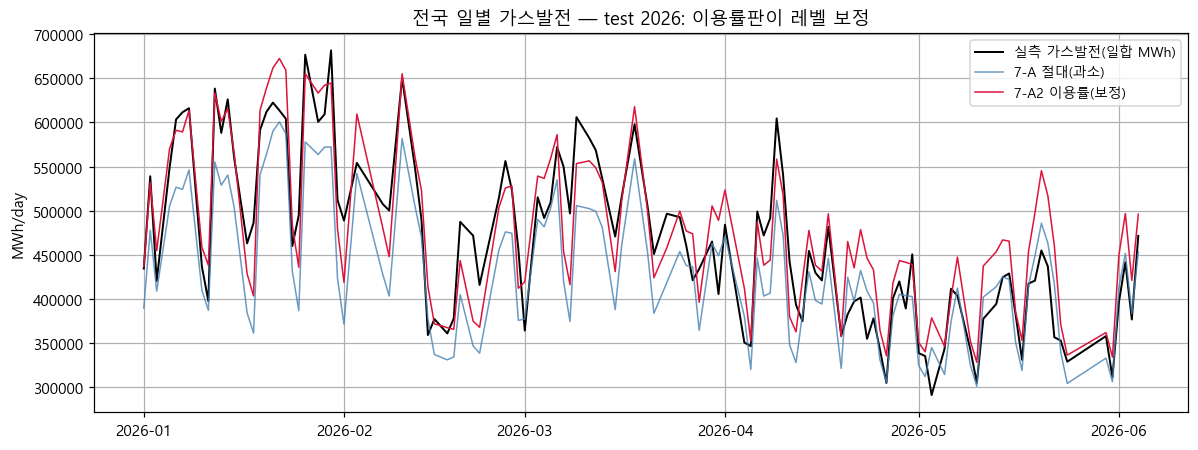

신재생 대체효과(이용률판 PDP, 복원 MW 기준) 기울기 = -0.1465 MW/MW (7-A 절대 −0.017과 동방향)


In [4]:
te=te.copy(); te['pred_abs']=pte_a; te['pred_util']=pte_u
dd=te.groupby(te.timestamp.dt.floor('D')).agg(act=('gen_gas_kr','sum'),pa=('pred_abs','sum'),
        pu=('pred_util','sum'),h=('gen_gas_kr','size')).reset_index()
dd=dd[dd.h==24]
fig,ax=plt.subplots(figsize=(11,4.2))
ax.plot(dd.timestamp,dd.act,color='black',lw=1.3,label='실측 가스발전(일합 MWh)')
ax.plot(dd.timestamp,dd.pa,color='steelblue',lw=1,alpha=0.8,label='7-A 절대(과소)')
ax.plot(dd.timestamp,dd.pu,color='crimson',lw=1,label='7-A2 이용률(보정)')
ax.set_title('전국 일별 가스발전 — test 2026: 이용률판이 레벨 보정'); ax.set_ylabel('MWh/day'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIG/'7a2_pred_compare.png'); plt.show()

# 신재생 대체효과 PDP(이용률 모델, 복원 스케일): renew 스윕
base=tr[FEATS].copy()
gridv=np.linspace(tr['renew_gen_total_kr'].quantile(.05),tr['renew_gen_total_kr'].quantile(.95),20)
capmed=df['LNG_cap'].median()
pdp=[]
for v in gridv:
    b=base.copy(); b['renew_gen_total_kr']=v
    pdp.append((m_util.predict(b).mean())*capmed)
slope=np.polyfit(gridv,pdp,1)[0]
print('신재생 대체효과(이용률판 PDP, 복원 MW 기준) 기울기 = %.4f MW/MW (7-A 절대 −0.017과 동방향)'%slope)


## 4. 저장 — 이용률 모델 + 메타
서빙 시: 예측 이용률 × 해당 시점 LNG_cap → 절대 가스발전(MW). 용량 파일 끝 이후는 최신 용량 ffill.

In [5]:
m_util.booster_.save_model('lgbm_land_gas_util.txt')
meta={'features':FEATS,'target':'util(=gen_gas_kr/LNG_cap)','restore':'pred_util × LNG_cap',
      'capacity_source':'kr_elec_capa.csv (월별, 끝 이후 ffill)',
      'best_iteration':int(m_util.best_iteration_),
      'window':'train 2022-2024 / val 2025 / test 2026',
      'metrics_test':{k:round(float(v),3) for k,v in metrics(yte,pte_u).items()},
      'metrics_test_7A_abs':{k:round(float(v),3) for k,v in metrics(yte,pte_a).items()},
      'note':'7-A 절대 타깃의 2026 과소예측(설비증설 표류)을 이용률 정규화로 보정. 피처는 7-A 동일.'}
json.dump(meta,io.open('model_meta_util.json','w',encoding='utf-8'),ensure_ascii=False,indent=2)
# 서빙용 용량 테이블도 저장(ffill 반영)
cap.to_csv(TAB/'7a2_lng_capacity_monthly.csv',index=False)
print('saved: lgbm_land_gas_util.txt, model_meta_util.json, tab/7a2_lng_capacity_monthly.csv')
print(json.dumps(meta['metrics_test'],ensure_ascii=False))


saved: lgbm_land_gas_util.txt, model_meta_util.json, tab/7a2_lng_capacity_monthly.csv
{"MAE": 1807.517, "RMSE": 2247.191, "MAPE": 10.513, "R2": 0.863, "bias": 4.043}
